In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
data= pd.read_csv('/content/loan_approval_dataset.csv')
data.head()


,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [ ]:
data.describe()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


# Data Preprocessing

In [ ]:
#Missing values
data.isnull().sum()

,0
loan_id,0
no_of_dependents,0
education,0
self_employed,0
income_annum,0
loan_amount,0
loan_term,0
cibil_score,0
residential_assets_value,0
commercial_assets_value,0


In [ ]:
#Dupes
data.duplicated().any()

np.False_

/tmp/ipykernel_806/2796954555.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='loan_status', data=data, palette='viridis')


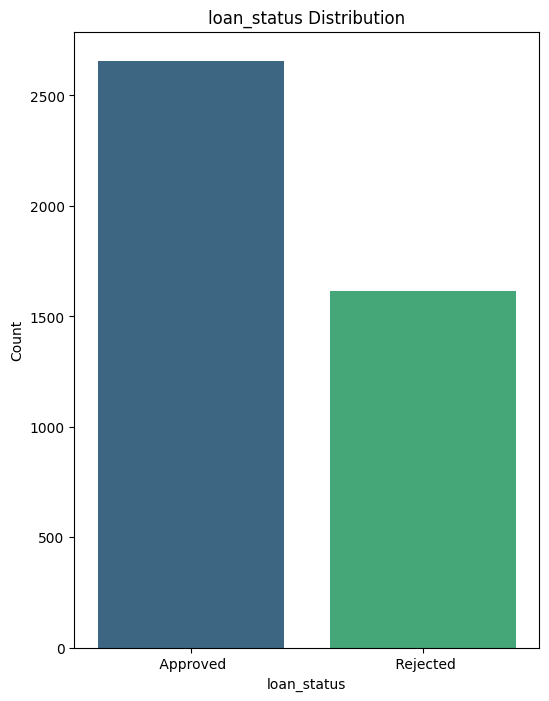

In [ ]:
#data visulaization
plt.figure(figsize=(6,8))
sns.countplot(x='loan_status', data=data, palette='viridis')
plt.title('loan_status Distribution')
plt.xlabel('loan_status')
plt.ylabel('Count')
plt.show()

In [ ]:
data['education'].unique()
data['self_employed'].unique()
data['loan_status'].unique()

array([' Approved', ' Rejected'], dtype=object)

In [ ]:
#loan_id removing
data.drop('loan_id', axis=1, inplace=True)

In [ ]:
#text data replacing
data['education'] = data['education'].str.strip().replace({'Graduate':1,'Not Graduate':0})
data['self_employed'] = data['self_employed'].str.strip().replace({'Yes':1,'No':0})
data['loan_status'] = data['loan_status'].str.strip().replace({'Approved':1,'Rejected':0})

/tmp/ipykernel_806/3898253924.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['education'] = data['education'].str.strip().replace({'Graduate':1,'Not Graduate':0})
/tmp/ipykernel_806/3898253924.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['self_employed'] = data['self_employed'].str.strip().replace({'Yes':1,'No':0})
/tmp/ipykernel_806/3898253924.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer

In [ ]:
data.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,1,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,1
1,0,0,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0
2,3,1,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0
3,3,1,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0
4,5,0,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0


# Divide the data into features and label

In [ ]:
x= data.iloc[:, 0:11]
y= data.iloc[:, 11]

In [ ]:
x.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
0,2,1,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000
1,0,0,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000
2,3,1,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000
3,3,1,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000
4,5,0,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000


# Scaling

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler_x = MinMaxScaler(feature_range=(0,1))



In [ ]:
x= scaler_x.fit_transform(x)


In [ ]:
x

array([[0.4       , 1.        , 0.        , ..., 0.90721649, 0.57583548,
        0.54421769],
       [0.        , 0.        , 1.        , ..., 0.11340206, 0.218509  ,
        0.2244898 ],
       [0.6       , 1.        , 0.        , ..., 0.23195876, 0.84832905,
        0.8707483 ],
       ...,
       [0.4       , 0.        , 0.        , ..., 0.63917526, 0.45758355,
        0.49659864],
       [0.2       , 0.        , 0.        , ..., 0.03608247, 0.35475578,
        0.39455782],
       [0.2       , 1.        , 0.        , ..., 0.60824742, 0.91002571,
        0.81632653]])

# Split the data into training and test sets

In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
len(y_train)

3415

#Apply K Fold Cross Validation

In [ ]:
from sklearn.model_selection import KFold, cross_val_score, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier



In [ ]:
#Apply K Fold Cross Validation
KF= KFold(n_splits=5, shuffle=True, random_state=42)

#Define the models
Models= {
    'DecisionTree': DecisionTreeClassifier(),
    'RandomForest': RandomForestClassifier()
}

# Define parameter sidtributions for each model
param_dists = {
    'DecisionTree': {
        'max_depth': [None, 5, 10, 15],
        'min_samples_split': [2, 3, 4, 5, 6, 8, 10],
        'min_samples_leaf': [1, 2, 4]
    },
    'RandomForest': {
        'n_estimators': [50, 100, 150, 200],
        'max_depth': [None, 5, 10, 15],
        'min_samples_leaf': [1, 2, 4]}
}

# Run Rondomized search for each model
results={}
for name, model in Models.items():
  print(f"Randomizedsearchcv for {name}...")
  search= RandomizedSearchCV(
  estimator= model,
  param_distributions=param_dists[name],
  n_iter=10,
  cv= KF,
  scoring= 'accuracy',
  random_state=42,
  n_jobs=-1
  )

  search.fit(x_train, y_train)
  results[name]= {
      'best_params': search.best_params_,
      'best_score': search.best_score_
  }

  #Display the result
for name, result in results.items():
  print(f"{name} Best Parameters: {result['best_params']}")




Randomizedsearchcv for DecisionTree...
Randomizedsearchcv for RandomForest...
DecisionTree Best Parameters: {'min_samples_split': 6, 'min_samples_leaf': 4, 'max_depth': None}
RandomForest Best Parameters: {'n_estimators': 150, 'min_samples_leaf': 1, 'max_depth': 10}


# Classification report for each model

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix


DecisionTree Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.96      0.96       318
           1       0.98      0.98      0.98       536

    accuracy                           0.97       854
   macro avg       0.97      0.97      0.97       854
weighted avg       0.97      0.97      0.97       854



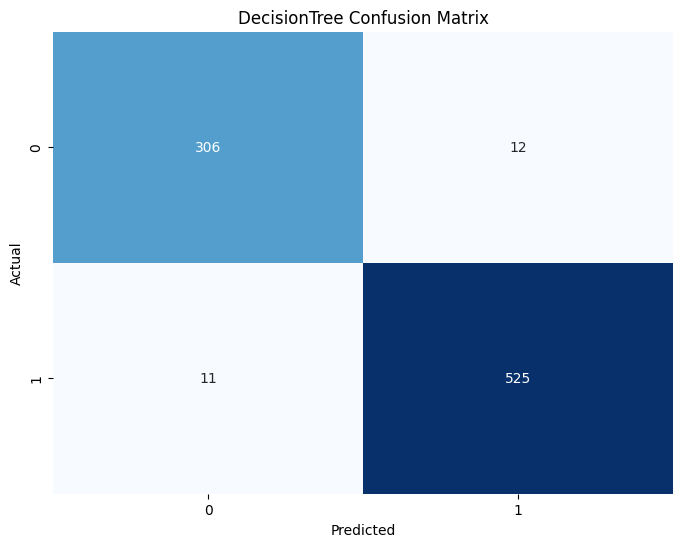

RandomForest Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.96      0.97       318
           1       0.97      0.99      0.98       536

    accuracy                           0.98       854
   macro avg       0.98      0.97      0.97       854
weighted avg       0.98      0.98      0.98       854



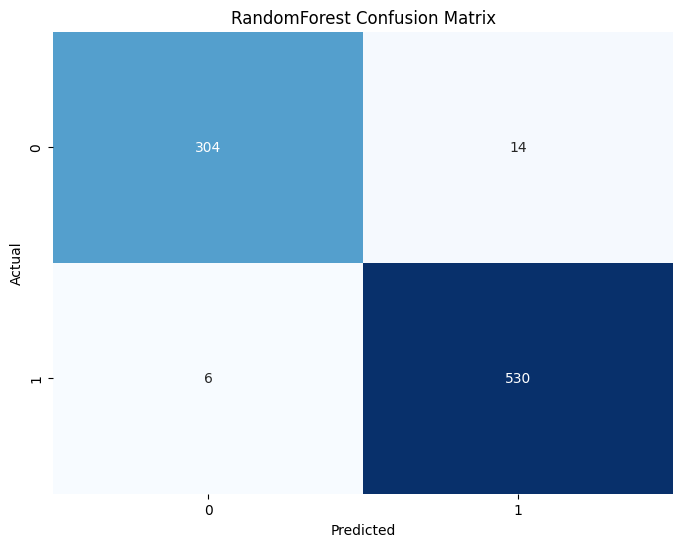


Summary of Model Performance:


,Model,Accuracy,Precision,Recall,F1-Score
0,DecisionTree,0.973068,0.977654,0.979478,0.978565
1,RandomForest,0.976581,0.974265,0.988806,0.981481


In [ ]:
# Create instances of the best models using the parameters from RandomizedSearchCV

best_models= {
    'DecisionTree': DecisionTreeClassifier(**results['DecisionTree']['best_params']),
    'RandomForest': RandomForestClassifier(**results['RandomForest']['best_params'])
}

#create a dictionary to store the results
result_dic= {
    'Model':[],
    'Accuracy':[],
    'Precision':[],
    'Recall':[],
    'F1-Score':[]
}

# Display classification report and store metrics for each model
for name, model in best_models.items():
  model.fit(x_train, y_train)
  y_pred= model.predict(x_test)

  report= classification_report(y_test, y_pred, output_dict=True)
  cm = confusion_matrix(y_test, y_pred)

  result_dic['Model'].append(name)
  result_dic['Accuracy'].append(report['accuracy'])
  result_dic['Precision'].append(report['1']['precision'])
  result_dic['Recall'].append(report['1']['recall'])
  result_dic['F1-Score'].append(report['1']['f1-score'])

  print(f"{name} Classification Report:")
  print(classification_report(y_test, y_pred))

  #Display Confusion Matrix
  plt.figure(figsize=(8,6))
  sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
  plt.title(f'{name} Confusion Matrix')
  plt.xlabel('Predicted')
  plt.ylabel('Actual')
  plt.show()

# Create a pandas DataFrame from the results dictionary
results_df = pd.DataFrame(result_dic)

# Display the results DataFrame
print("\nSummary of Model Performance:")
display(results_df)

